<a href="https://colab.research.google.com/github/tadesseabera95-ship-it/Phishing-Detection-ML/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [65]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.linear_model  import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
import matplotlib.pyplot as plt
import plotly.express as px
import re
import seaborn as sns

In [30]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [33]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

1.DATASET LOADING

In [3]:
df=pd.read_csv('/Phishing_Email.csv')

In [4]:
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [5]:
df

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email
...,...,...,...
18645,18646,date a lonely housewife always wanted to date ...,Phishing Email
18646,18647,request submitted : access request for anita ....,Safe Email
18647,18648,"re : important - prc mtg hi dorn & john , as y...",Safe Email
18648,18649,press clippings - letter on californian utilit...,Safe Email


2.Data cleaning

In [6]:
df.shape

(18650, 3)

In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
Email Text,16
Email Type,0


In [8]:
df.duplicated().sum()

np.int64(0)

The dataset have 16 missing values and one  Unnamed 0 columns

In [9]:
# Drop duplicates and null values
df.drop(["Unnamed: 0"],axis=1,inplace=True)#modify on the dataset not generate new
df.dropna(inplace=True,axis=0) #Dropp the missing values
df.drop_duplicates(inplace=True)#modify on the dataset not generate new

In [10]:
df.shape

(17538, 2)

Labels of Safe and phishing email

In [81]:
fig = px.bar(df['Email Type'].value_counts(),
               x=df['Email Type'].value_counts().index,
               y=df['Email Type'].value_counts().values,
               color=['blue', 'red'],
               labels={'x': 'Email Type (1: Safe, 0: Phishing)', 'y': 'Count'},
               title="Categorical Distribution of Email Types",
               width=500, height=400) # Adjusting width and height to reduce size
fig.show()

In [14]:
# Create the pie chart
fig_pie = px.pie(df['Email Type'].value_counts(), names=df['Email Type'].value_counts().index,
                 values=df['Email Type'].value_counts().values, title="Categorical Distribution")

# Show the pie chart
fig_pie.show()

In [15]:
print(df['Email Type'].value_counts())

Email Type
Safe Email        10980
Phishing Email     6558
Name: count, dtype: int64


**3.Text Preprocessing**


1.Punctuation Removal

2.Lowercasing

3.Tokenization

4.StopWord Removal

5.Lemmatization

In [22]:
#Encode labels to integers for easier handling
le = LabelEncoder()

df["Email Type"] = le.fit_transform(df["Email Type"])

In [20]:
df

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",1
1,the other side of * galicismos * * galicismo *...,1
2,re : equistar deal tickets are you still avail...,1
3,\nHello I am your hot lil horny toy.\n I am...,0
4,software at incredibly low prices ( 86 % lower...,0
...,...,...
18644,\nRick Moen a Ã©crit:> > I'm confused. I thou...,1
18645,date a lonely housewife always wanted to date ...,0
18646,request submitted : access request for anita ....,1
18647,"re : important - prc mtg hi dorn & john , as y...",1


In [39]:
# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Updated Text Cleaning Function
def preprocess_text(text):
    # Remove hyperlinks
    text = re.sub(r'http\S+', '', text)

    # Remove punctuations
    text = re.sub(r'[^\w\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    tokens = nltk.word_tokenize(text)

    # StopWord Removal
    tokens = [t for t in tokens if t not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)


# Apply the updated preprocess_text function to the specified column in the DataFrame
df["Email Text"] = df["Email Text"].apply(preprocess_text)

display(df.tail())

,Email Text,Email Type
18644,rick moen ãcrit im confused thought gpled mone...,1
18645,date lonely housewife always wanted date lonel...,0
18646,request submitted access request anita dupont ...,1
18647,important prc mtg hi dorn john discovered rece...,1
18648,press clipping letter californian utility plea...,1


TF-IDF Vectorisation

TF-IDF (Term Frequency – Inverse Document Frequency):


TF(t, d)  = (number of times term t appears in document d)
            / (total number of terms in d)

IDF(t)    = log( N / (1 + df(t)) )
            where N = total documents, df(t) = documents containing term t

TF-IDF(t, d) = TF(t, d) × IDF(t)

In [44]:
tf = TfidfVectorizer(stop_words="english",token_pattern=r'(?u)\b[a-zA-Z]{2,}\b', ngram_range=(1, 2), # Remove English stopwords before computing TF-IDF
max_features=10000) #dimensionality reduction to avoid memory issues
                     # Keep only the top 10,000 most informative words

feature_x = tf.fit_transform(df["Email Text"]).toarray() # fit_transform: Learns the vocabulary (fit) and converts emails to vectors (transform).
# .toarray(): Converts sparse matrix → dense numpy array (required by some models).
# Result shape: (n_emails, 10000) — each email is a vector of 10,000 TF-IDF scores.
y_tf = np.array(df['Email Type']) # convert the label into numpy array

In [26]:
#combine all rows into a single string
all_mails = " ".join(df['Email Text'])

Parameters

In [45]:
# PARAMETERS
test_size = 0.2                                 # test size (default: 0.2 [20 %])
train_size = 1 - test_size                      # train size (default: 0.8 [80 %])

print("| PARAMETERS: |\n")


print("Train Size: {} %".format(train_size*100))
print("Test Size: {} %".format(test_size*100))

| PARAMETERS: |

Train Size: 80.0 %
Test Size: 20.0 %


4.MODEL DEFINITION

In [66]:
# Define LinearSVM
# Use LinearSVM for large datasets, as it's faster than SVC with a linear kernel
model_svm = LinearSVC(random_state=42, max_iter=1000)

In [53]:
# define Random Forest
model_rf = RandomForestClassifier(n_estimators=100,
                                  random_state=42)

In [48]:
# define XGBoost
model_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss')

In [49]:
# define CatBoost
model_cb = CatBoostClassifier(iterations=100)
print("Model: CatBoost Classifier")

Model: CatBoost Classifier


### Data Splitting

In [56]:
X_train, X_test, y_train, y_test = train_test_split(feature_x, y_tf, test_size=0.2, random_state=42, stratify=y_tf)


5.MODEL TRAINING

In [67]:
# Train the SVM model
model_svm.fit(X_train, y_train)
print("LinearSVM model trained.")

# Train the Random Forest model
model_rf.fit(X_train, y_train)
print("Random Forest model trained.")

# Train the XGBoost model
model_xgb.fit(X_train, y_train)
print("XGBoost model trained.")

# Train the CatBoost model
model_cb.fit(X_train, y_train)
print("CatBoost model trained.")

LinearSVM model trained.
Random Forest model trained.
XGBoost model trained.
Learning rate set to 0.262862
0:	learn: 0.5525664	total: 1.62s	remaining: 2m 39s
1:	learn: 0.4810909	total: 3.43s	remaining: 2m 48s
2:	learn: 0.4279386	total: 4.96s	remaining: 2m 40s
3:	learn: 0.4002305	total: 6.01s	remaining: 2m 24s
4:	learn: 0.3768083	total: 7.07s	remaining: 2m 14s
5:	learn: 0.3518941	total: 8.12s	remaining: 2m 7s
6:	learn: 0.3250157	total: 9.17s	remaining: 2m 1s
7:	learn: 0.3086356	total: 10.2s	remaining: 1m 57s
8:	learn: 0.2958637	total: 11.3s	remaining: 1m 53s
9:	learn: 0.2857005	total: 12.4s	remaining: 1m 51s
10:	learn: 0.2783017	total: 13.4s	remaining: 1m 48s
11:	learn: 0.2703598	total: 14.5s	remaining: 1m 46s
12:	learn: 0.2610927	total: 16.2s	remaining: 1m 48s
13:	learn: 0.2520771	total: 17.9s	remaining: 1m 49s
14:	learn: 0.2441634	total: 18.9s	remaining: 1m 47s
15:	learn: 0.2327418	total: 20s	remaining: 1m 45s
16:	learn: 0.2257610	total: 21.1s	remaining: 1m 42s
17:	learn: 0.2184595	to

### Model Evaluation

In [68]:
# Make predictions on the test set for LinearSVM
y_pred_svm = model_svm.predict(X_test)
print("LinearSVM Evaluation:")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

# Make predictions on the test set for Random Forest
y_pred_rf = model_rf.predict(X_test)
print("\nRandom Forest Evaluation:")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Make predictions on the test set for XGBoost
y_pred_xgb = model_xgb.predict(X_test)
print("\nXGBoost Evaluation:")
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Make predictions on the test set for CatBoost
y_pred_cb = model_cb.predict(X_test)
print("\nCatBoost Evaluation:")
print(classification_report(y_test, y_pred_cb))
print("Accuracy:", accuracy_score(y_test, y_pred_cb))

LinearSVM Evaluation:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1312
           1       0.98      0.98      0.98      2196

    accuracy                           0.98      3508
   macro avg       0.98      0.98      0.98      3508
weighted avg       0.98      0.98      0.98      3508

Accuracy: 0.9774800456100342

Random Forest Evaluation:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1312
           1       0.97      0.97      0.97      2196

    accuracy                           0.96      3508
   macro avg       0.96      0.96      0.96      3508
weighted avg       0.96      0.96      0.96      3508

Accuracy: 0.9643671607753705

XGBoost Evaluation:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1312
           1       0.95      0.97      0.96      2196

    accuracy                           0.95      3508



LinearSVM Confusion Matrix:


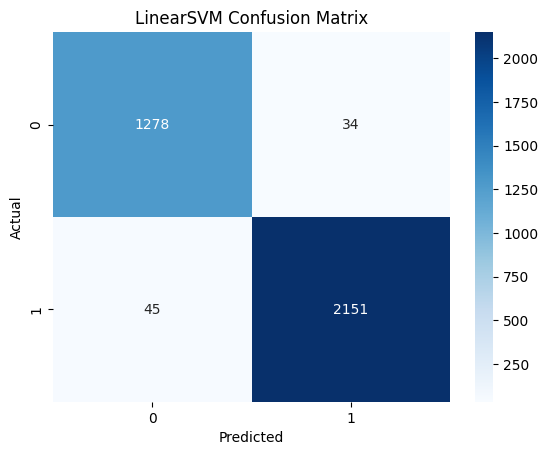


Random Forest Confusion Matrix:


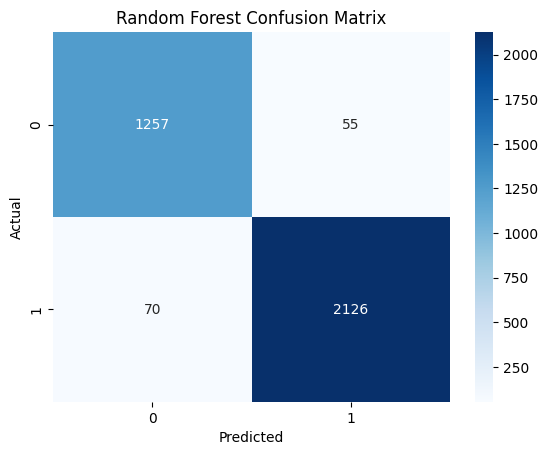


XGBoost Confusion Matrix:


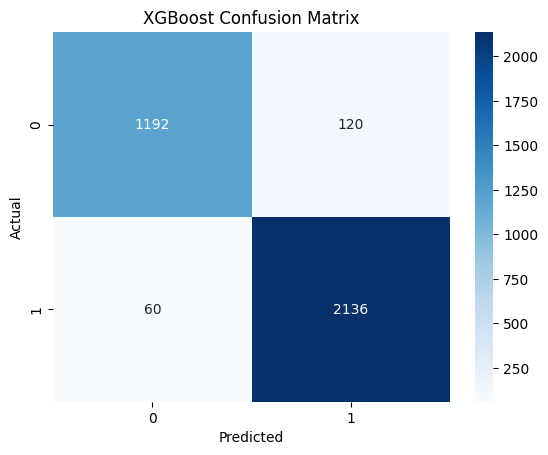


CatBoost Confusion Matrix:


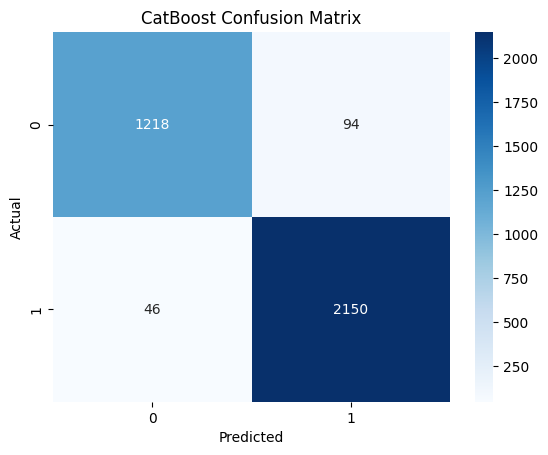

In [69]:
print("\nLinearSVM Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title('LinearSVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nRandom Forest Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nXGBoost Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nCatBoost Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_cb), annot=True, fmt='d', cmap='Blues')
plt.title('CatBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Ensemble Model: Majority Voting

In [70]:
# Create a list of (name, estimator) tuples for the VotingClassifier
en_estimators = [
    ('svm', model_svm),
    ('rf', model_rf),
    ('xgb', model_xgb),
    ('cb', model_cb)
]

# Create the VotingClassifier with soft voting (probability based)
voting_clf = VotingClassifier(estimators=en_estimators, voting='soft', n_jobs=-1)

# Train the VotingClassifier
voting_clf.fit(X_train, y_train)
print("Ensemble Majority Voting Classifier trained.")

Ensemble Majority Voting Classifier trained.



Ensemble Majority Voting Evaluation:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1312
           1       0.98      0.98      0.98      2196

    accuracy                           0.97      3508
   macro avg       0.97      0.97      0.97      3508
weighted avg       0.97      0.97      0.97      3508

Accuracy: 0.9734891676168758

Ensemble Majority Voting Confusion Matrix:


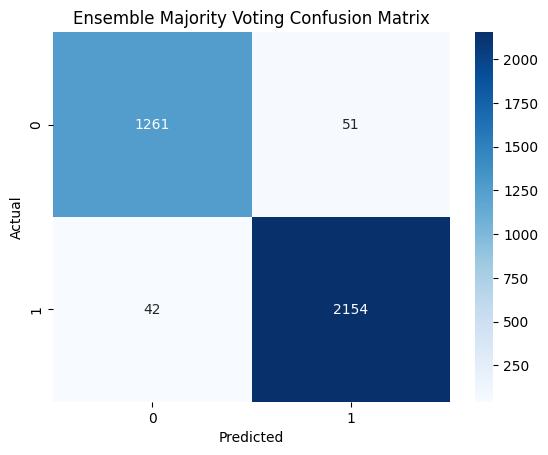

In [61]:
# Make predictions on the test set for the VotingClassifier
y_pred_ensemble = voting_clf.predict(X_test)
print("\nEnsemble Majority Voting Evaluation:")
print(classification_report(y_test, y_pred_ensemble))
print("Accuracy:", accuracy_score(y_test, y_pred_ensemble))

print("\nEnsemble Majority Voting Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_ensemble), annot=True, fmt='d', cmap='Blues')
plt.title('Ensemble Majority Voting Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Model Comparison Table

In [71]:
from sklearn.metrics import precision_score, f1_score

models = {
    'LinearSVM': y_pred_svm,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'CatBoost': y_pred_cb,
    'Ensemble (Voting)': y_pred_ensemble
}

results = []
for name, y_pred in models.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({'Model': name, 'Accuracy': accuracy, 'Precision': precision, 'F1-Score': f1})

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(comparison_df)

,Model,Accuracy,Precision,F1-Score
0,LinearSVM,0.977480,0.977538,0.977499
1,Ensemble (Voting),0.973489,0.973466,0.973471
2,Random Forest,0.964367,0.964485,0.964407
3,CatBoost,0.960091,0.960166,0.959935
4,XGBoost,0.948689,0.948779,0.948434


### Model Performance Visualization

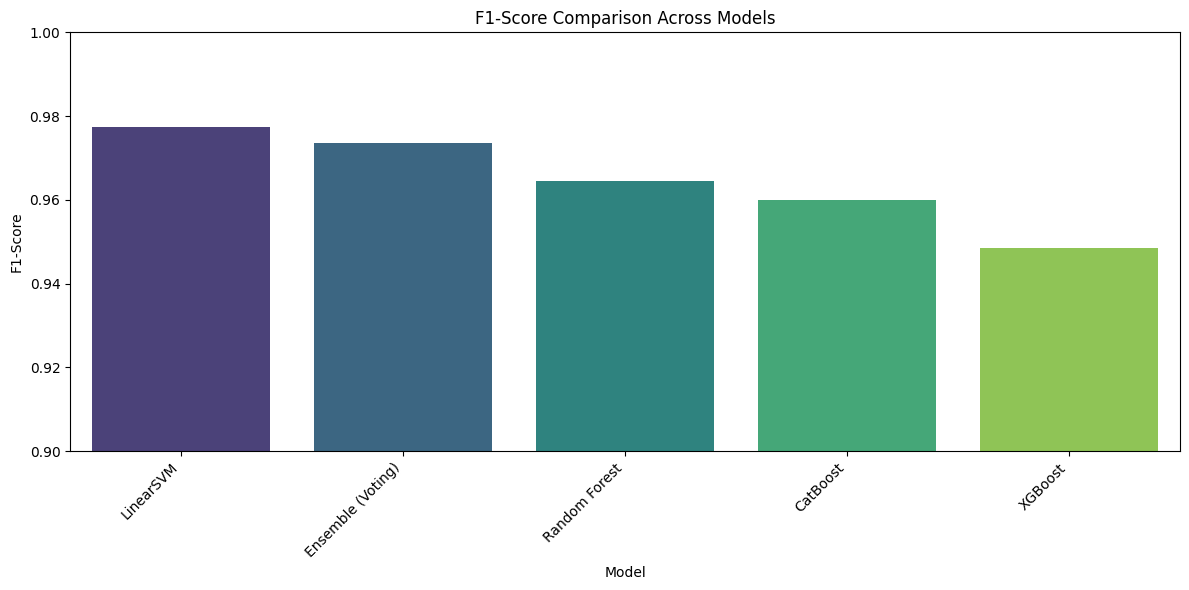

In [79]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1-Score', data=comparison_df, palette='viridis', hue='Model', legend=False)
plt.title('F1-Score Comparison Across Models')
plt.ylabel('F1-Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.9, 1.0) # Set a reasonable y-axis limit for better visibility of differences
plt.tight_layout()
plt.show()

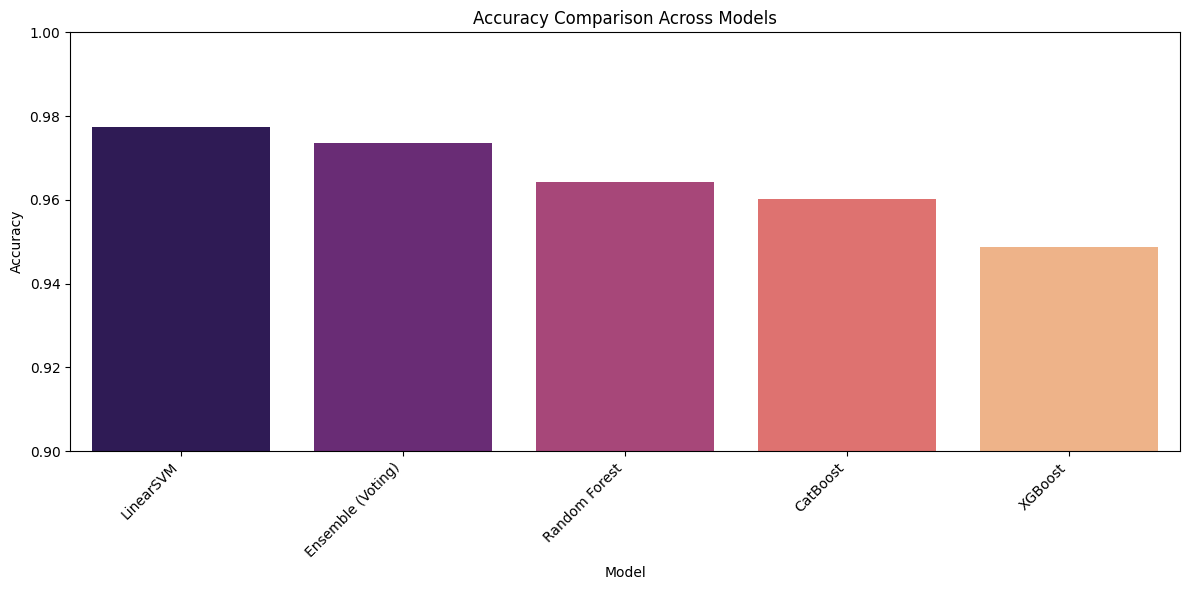

In [80]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='magma', hue='Model', legend=False)
plt.title('Accuracy Comparison Across Models')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.9, 1.0) # Set a reasonable y-axis limit for better visibility of differences
plt.tight_layout()
plt.show()